# Problema paramétrico 1D de contorno

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana03_pinn_parametrico.ipynb)

En este notebook se entrena una **red neuronal informada en física (PINN)** para resolver una **familia** de problemas estacionarios en una dimensión. La entrada de la red es $(x, \nu)$, donde:

- $x$ es la coordenada espacial en $[0, 1]$
- $\nu$ es un parámetro tipo viscosidad en $[0.1, 1.1]$
- la salida de la red es la solución escalar $u(x, \nu)$

La ecuación diferencial que analizaremos sera la de advección-difusión estacionaria, dada por

$$
\partial_x u - \nu \, \partial_{xx} u = 1, \qquad x \in [0,1].
$$

Para cada valor de $\nu$, las condiciones de contorno son

$$
u(0, \nu) = 0, \qquad u(1, \nu) = 0.
$$

Por lo tanto, el notebook no está resolviendo una PDE espacial en dos dimensiones: la segunda coordenada es un **parámetro**, y la PINN aprende de una sola vez el mapa completo para muchas viscosidades.


In [16]:
import numpy as np
import time
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import qmc
torch.set_default_dtype(torch.float32)

_ACTIVATIONS = {
    "relu": nn.ReLU,
    "sigmoid": nn.Sigmoid,
    "softplus": nn.Softplus,
    "tanh": nn.Tanh,
}


class FeedForwardPINN(nn.Module):
    def __init__(
        self,
        in_shape=2,
        out_shape=1,
        n_hidden_layers=5,
        neuron_per_layer=20,
        actfn="tanh",
        name=None,
    ):
        super().__init__()
        activation_cls = _ACTIVATIONS.get(actfn.lower())
        if activation_cls is None:
            raise ValueError(f"Unsupported activation: {actfn}")

        layers = []
        input_dim = in_shape
        for _ in range(n_hidden_layers):
            layers.append(nn.Linear(input_dim, neuron_per_layer))
            layers.append(activation_cls())
            input_dim = neuron_per_layer
        layers.append(nn.Linear(input_dim, out_shape))

        self.network = nn.Sequential(*layers)
        self.name = name or f"DNN-{n_hidden_layers}"

    def forward(self, inputs):
        return self.network(inputs)


def build_mlp(
    in_shape=2,
    out_shape=1,
    n_hidden_layers=5,
    neuron_per_layer=20,
    actfn="tanh",
):
    return FeedForwardPINN(
        in_shape=in_shape,
        out_shape=out_shape,
        n_hidden_layers=n_hidden_layers,
        neuron_per_layer=neuron_per_layer,
        actfn=actfn,
    )


def to_torch(value, requires_grad=False):
    if isinstance(value, torch.Tensor):
        tensor = value
        if tensor.is_floating_point():
            tensor = tensor.to(dtype=torch.get_default_dtype())
        tensor = tensor.clone().detach()
    else:
        tensor = torch.as_tensor(value)
        if tensor.is_floating_point():
            tensor = tensor.to(dtype=torch.get_default_dtype())

    if requires_grad:
        tensor.requires_grad_(True)
    return tensor


def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
    )[0]


def describe_model(model):
    total_params = sum(parameter.numel() for parameter in model.parameters())
    trainable_params = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )

    print(model)
    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")

## Solución exacta y por qué este ejemplo es útil

Este es un problema de contorno del tipo advección-difusión con solución analítica cerrada:

$$
u(x, \nu) = x - \frac{e^{(x-1)/\nu} - e^{-1/\nu}}{1 - e^{-1/\nu}}.
$$

Más adelante se usa esta fórmula exacta para validar la PINN. La idea central del ejemplo es mostrar que una sola red puede aproximar el mapa completo $(x, \nu) \mapsto u(x, \nu)$ en lugar de resolver la PDE por separado para cada viscosidad.


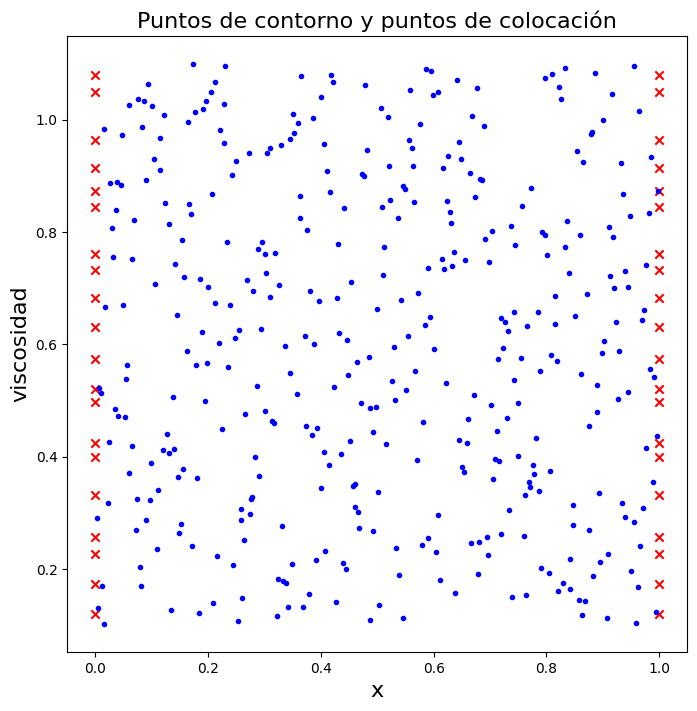

In [17]:
### generación de datos
n_bc = 2
n_data_per_bc = 20
#
engine = qmc.LatinHypercube(d=1)
data = np.zeros([2 ,n_data_per_bc , 3])


for i, j in zip(range(n_bc), [0, +1, 0, +1]):
    points = (engine.random(n=n_data_per_bc)[:, 0] - 0.) * 1    
    data[i, :, 0] = j
    data[i, :, 1] = points

data[0, :, 1] =  data[i, :, 1] + 0.1
data[1, :, 1] =  data[i, :, 1] + 0.1

# Valores de contorno
# La viscosidad queda almacenada en y_d (segunda componente)
# y varía entre 0.1 y 1.1.
for j in range(0,n_data_per_bc):    
    data[0, j, 2] = 0
    data[1, j, 2] = 0

data = data.reshape(n_data_per_bc * n_bc, 3)
#
x_d, y_d, t_d = map(lambda x: np.expand_dims(x, axis=1), 
                    [data[:, 0], data[:, 1], data[:, 2]])
#
Nc = 400
engine = qmc.LatinHypercube(d=2)
colloc = engine.random(n=Nc)
colloc = 1 * (colloc -0.)
colloc[:, 1] =  colloc[:, 1] + 0.1
#
x_c, y_c = map(lambda x: np.expand_dims(x, axis=1), 
               [colloc[:, 0], colloc[:, 1]])

#
plt.figure("", figsize=(8, 8))
plt.title("Puntos de contorno y puntos de colocación",fontsize=16)

plt.scatter(data[:, 0], data[:, 1], marker="x", c="r", label="contorno")
plt.scatter(colloc[:, 0], colloc[:, 1],  marker=".", c="b", label="colocación")
plt.xlabel("x",fontsize=16)
plt.ylabel("viscosidad",fontsize=16)
plt.show()
#

x_c, y_c = map(lambda x: to_torch(x, requires_grad=True), [x_c, y_c])
x_d, y_d, t_d = map(to_torch, [x_d, y_d, t_d])

## Estrategia de muestreo

Abajo se generan dos tipos de puntos:

- **Puntos de contorno** en $x = 0$ y $x = 1$, para muchos valores de $\nu$
- **Puntos de colocación** en el interior del dominio $(x, \nu)$, donde se minimiza el residuo de la PDE

En el código, la segunda coordenada se guarda en la variable $y$, pero conceptualmente representa al parámetro $\nu$.


In [18]:
### función constructora del modelo
def DNN_builder(in_shape=2, out_shape=1, n_hidden_layers=5, 
                neuron_per_layer=60, actfn="tanh"):
    return build_mlp(
        in_shape=in_shape,
        out_shape=out_shape,
        n_hidden_layers=n_hidden_layers,
        neuron_per_layer=neuron_per_layer,
        actfn=actfn,
    )


In [19]:
model = DNN_builder(2, 1, 5, 60, "tanh")
describe_model(model)


FeedForwardPINN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=60, bias=True)
    (1): Tanh()
    (2): Linear(in_features=60, out_features=60, bias=True)
    (3): Tanh()
    (4): Linear(in_features=60, out_features=60, bias=True)
    (5): Tanh()
    (6): Linear(in_features=60, out_features=60, bias=True)
    (7): Tanh()
    (8): Linear(in_features=60, out_features=60, bias=True)
    (9): Tanh()
    (10): Linear(in_features=60, out_features=1, bias=True)
  )
)
Total parameters: 14881
Trainable parameters: 14881


## Red neuronal y residuo físico

El modelo es una red totalmente conectada que recibe $(x, \nu)$ como entrada y devuelve $u(x, \nu)$.

La parte física de la función de pérdida se construye a partir del residuo

$$
R(x, \nu) = \partial_x u - \nu \, \partial_{xx} u - 1.
$$

Para calcular $u_x$ y $u_{xx}$ respecto de la coordenada espacial $x$ usamos diferenciación automática.

In [20]:
def u(x, y):
    u = model(torch.cat([x, y], dim=1))
    return u

In [21]:
def f(x, y):
    u0 = u(x, y)
    u_x = grad(u0, x)
    #u_y = grad(u0, y)
    u_xx = grad(u_x, x)
       
    F = u_x - y*(u_xx) - 1
    
    return torch.mean(F**2)

## Objetivo de entrenamiento

La optimización combina dos contribuciones:

- un **término físico** que empuja el residuo $R(x, \nu)$ hacia cero en los puntos de colocación
- un **término de contorno** que fuerza $u(0, \nu) = u(1, \nu) = 0$

Esta es la formulación estándar de una PINN con restricciones suaves:

$$
\mathcal{L} = \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}.
$$


    0, 1.03397357
  200, 0.13107544
  400, 0.12287806
  600, 0.05913652
  800, 0.03630741
 1000, 0.02522833
 1200, 0.02005674
 1400, 0.01252284
 1600, 0.00906156
 1800, 0.00620640
 2000, 0.00376843
 2200, 0.00213453
 2400, 0.00130460
 2600, 0.00086663
 2800, 0.00059547
 2999, 0.00041782

computation time: 14.375



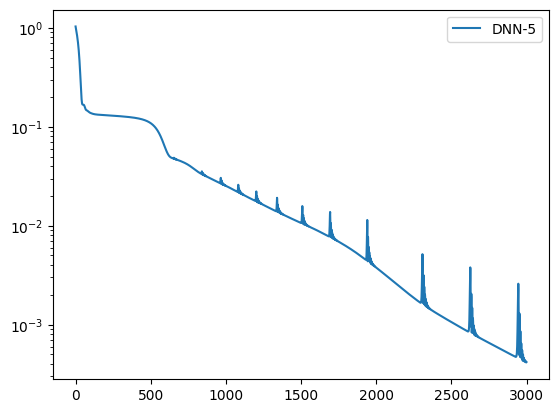

In [22]:
loss = 0
epochs = 3000
opt = torch.optim.Adam(model.parameters(), lr=2e-4)
epoch = 0
loss_values = np.array([])
criterion = nn.MSELoss()
start = time.time()
#
for epoch in range(epochs):
    opt.zero_grad()
    T_ = u(x_d, y_d)
    L = f(x_c, y_c)
    # El MSE se aplica a los valores objetivo del contorno.
    l = criterion(T_, t_d)
    loss = l+ L
    loss.backward()
    opt.step()
    loss_values = np.append(loss_values, loss.item())
    if epoch % 200 == 0 or epoch == epochs-1:
        print(f"{epoch:5}, {loss.item():.8f}")

#
end = time.time()
computation_time = {}
computation_time["pinn"] = end - start
print(f"\ncomputation time: {end-start:.3f}\n")
#
plt.semilogy(loss_values, label=model.name)
plt.legend()


## Gráficos de validación

Las figuras siguientes comparan la predicción de la PINN con la solución exacta en todo el dominio $(x, \nu)$.

- El primer panel muestra la superficie aprendida por la red.
- El segundo panel muestra la solución exacta.
- La figura final compara varios cortes 1D para viscosidades fijas.


(-0.005050505050505051,
 1.0050505050505054,
 0.09494949494949495,
 1.1050505050505053)

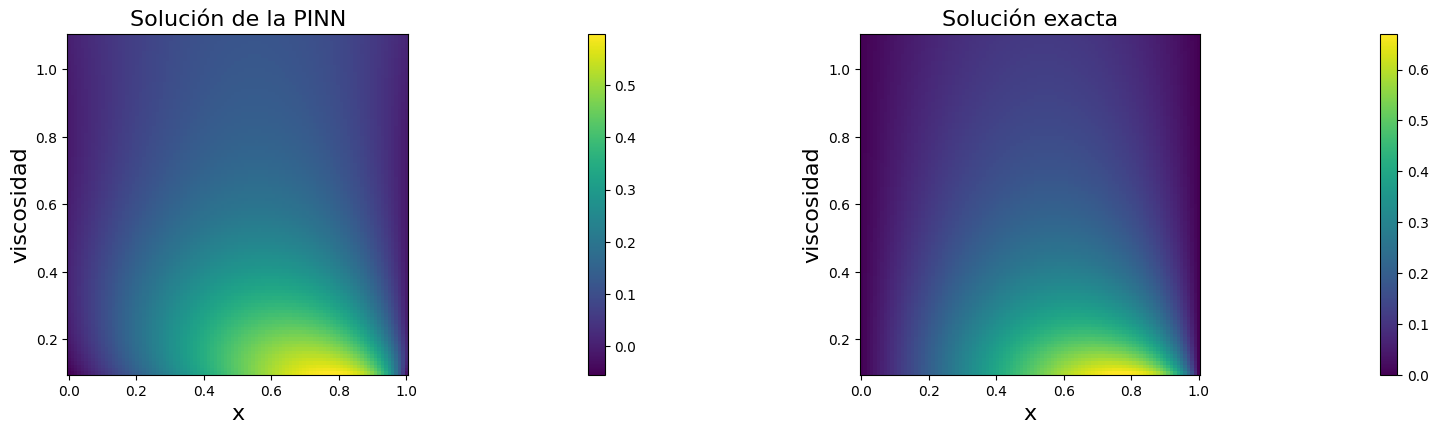

In [23]:
n = 100
### gráficos
plt.figure("", figsize=(16, 8))
#
X = np.linspace(0, +1, n)
Y = np.linspace(0.1, 1.1, n)
X0, Y0 = np.meshgrid(X, Y)
X = X0.reshape([n*n, 1])
Y = Y0.reshape([n*n, 1])
X_T = to_torch(X)
Y_T = to_torch(Y)
S = u(X_T, Y_T)
S = S.detach().cpu().numpy().reshape(n, n)
#
plt.subplot(221)
plt.pcolormesh(X0, Y0, 1.*S, cmap="viridis")
#plt.colorbar(pad=-0.25)
#plt.contour(x, y, S,14,linewidths=1.95)

plt.colorbar()
plt.xlabel("x",fontsize=16)
plt.ylabel("viscosidad",fontsize=16)
plt.title("Solución de la PINN",fontsize=16)
plt.tight_layout()
plt.axis("square")
#
x = np.linspace(0, +1, n)
y = np.linspace(0.1, 1.1, n)
x, y = np.meshgrid(x, y)


# Solución exacta y error.

T = x - (np.exp((x-1)/y) - np.exp(-1/y))/(1 - np.exp(-1/y))
TT = T -S

#
plt.subplot(222)
plt.pcolormesh(x, y, T, cmap="viridis")
plt.colorbar()
#plt.contour(x, y, T,14,linewidths=1.95)
plt.title(r"Solución exacta",fontsize=16)
plt.xlabel("x",fontsize=16)
plt.ylabel("viscosidad",fontsize=16)
plt.xlim(0, +1)
plt.ylim(0., 1)
plt.tight_layout()
plt.axis("square")
#plt.savefig("heat01.png")
#



## Cortes de la solución para viscosidades fijas

La figura final extrae varios perfiles 1D $u(x, \nu)$ para valores seleccionados de $\nu$. Suele ser la forma más clara de ver si la PINN captura correctamente cómo cambia la capa límite cuando disminuye la viscosidad.


[5, 19, 39, 89]


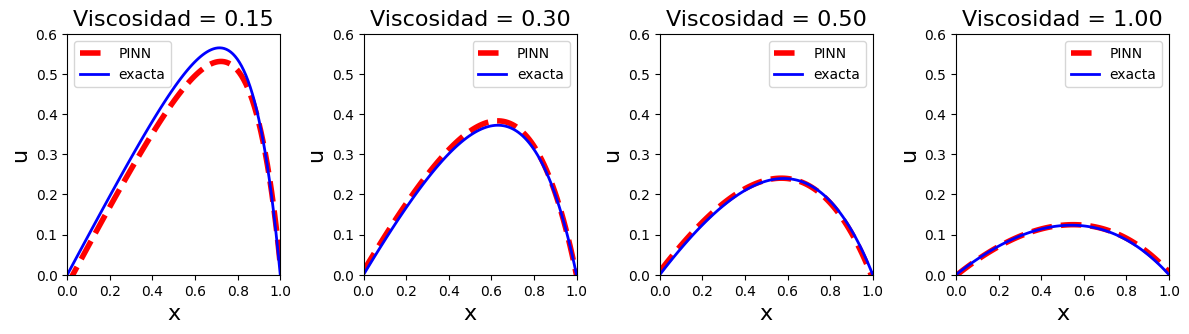

In [24]:
# Cálculo de perfiles para comparar PINN y solución exacta.
n=100
X = np.linspace(0, +1, n)
Y = np.linspace(0.1, +1.1, n)
X0, Y0 = np.meshgrid(X, Y)

X = X0.reshape([n*n, 1])
Y = Y0.reshape([n*n, 1])
X_T = to_torch(X)
Y_T = to_torch(Y)

Scomp = u(X_T, Y_T)

S = Scomp[:,0:1]
S = S.detach().cpu().numpy().reshape(n, n)
S_ = S.reshape([n, n])

# Solución exacta en la misma grilla.

T_ = X0 - (np.exp((X0-1)/Y0) - np.exp(-1/Y0))/(1 - np.exp(-1/Y0))


height = 3
frames_val = np.array([0.15, +.3, +.5, 1.])
frames = [*map(int, (frames_val + 1)/2 * (n-1))]

frames = [5, 19, 39, 89]
print(frames)


fig = plt.figure("", figsize=(len(frames)*height, 2*height))

for i, var_index in enumerate(frames):
    plt.subplot(2, len(frames), i+1)
    plt.title(f"Viscosidad = {frames_val[i]:.2f}",fontsize=16)
    plt.plot(X0[var_index, :], S_[var_index,:], "r--", lw=4., label="PINN")
    plt.plot(X0[var_index, :], T_[var_index,:], "b", lw=2., label="exacta")
    plt.ylim(0, 0.6)
    plt.xlim(0, 1.)
    plt.xlabel("x",fontsize=16)
    plt.ylabel("u",fontsize=16)
    plt.tight_layout()
    plt.legend()



